### EX: Handling the Unknown

In this exercise, we will prove how smoothing saves the model from catastrophic failure when encountering new tactics. You will execute the following steps:

* **Create Unbalanced Data:** Train a model where the word "missile" appears in the Urgent class, but has *never* been seen in the Routine class.
* **Train Two Models:** Train one Naive Bayes model with smoothing (`alpha=1.0`) and one without (`alpha=1e-10` to approximate zero).
* **The Test:** Ask both models to classify a seemingly Routine message that inexplicably contains the word "missile".
* **Visualize:** Plot how the non-smoothed model assigns a literal 0% chance, while the smoothed model intelligently calculates a balanced probability.


In [1]:
#Only run this cell after selecting your kernel
!python.exe -m pip install --upgrade pip
!pip install numpy matplotlib scikit-learn pandas

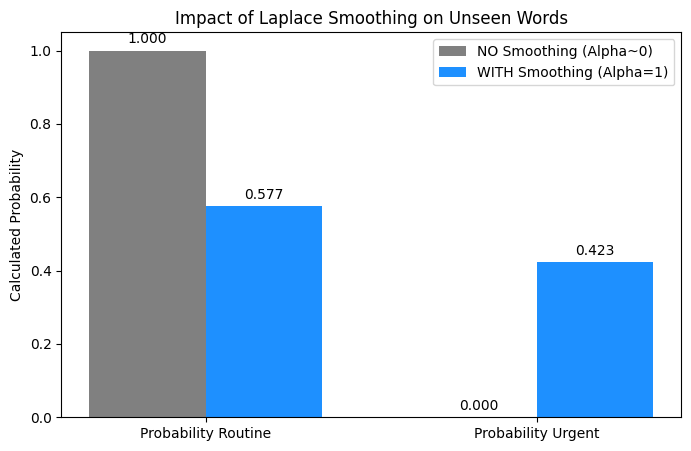

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.naive_bayes import MultinomialNB

# 1. Specialized Dataset to force a Zero-Frequency event
data_smooth = {
    'Text': [
        "enemy missile launch detected", "urgent missile inbound", # 'missile' is in Urgent
        "routine patrol complete", "chow hall is open", "weather is clear" # 'missile' NEVER in Routine
    ],
    'Label': ['Urgent', 'Urgent', 'Routine', 'Routine', 'Routine']
}
df_smooth = pd.DataFrame(data_smooth)
vec_smooth = CountVectorizer()
X_smooth = vec_smooth.fit_transform(df_smooth['Text'])

# 2. Train Model WITHOUT Smoothing (alpha approaches 0)
nb_no_smooth = MultinomialNB(alpha=1e-10) 
nb_no_smooth.fit(X_smooth, df_smooth['Label'])

# 3. Train Model WITH Laplace Smoothing (alpha = 1)
nb_smoothed = MultinomialNB(alpha=1.0)
nb_smoothed.fit(X_smooth, df_smooth['Label'])

# 4. Test on a tricky sentence: A mostly routine sentence with the zero-frequency word.
tricky_sentence = ["routine patrol spotted a missile"] # 'missile' was never in routine training data
X_tricky = vec_smooth.transform(tricky_sentence)

prob_no_smooth = nb_no_smooth.predict_proba(X_tricky)[0]
prob_smoothed = nb_smoothed.predict_proba(X_tricky)[0]

# 5. Plot the comparison
labels = ['Probability Routine', 'Probability Urgent']
x = np.arange(len(labels))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 5))
rects1 = ax.bar(x - width/2, prob_no_smooth, width, label='NO Smoothing (Alpha~0)', color='gray')
rects2 = ax.bar(x + width/2, prob_smoothed, width, label='WITH Smoothing (Alpha=1)', color='dodgerblue')

ax.set_ylabel('Calculated Probability')
ax.set_title('Impact of Laplace Smoothing on Unseen Words')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

# Add values on top of bars
ax.bar_label(rects1, padding=3, fmt='%.3f')
ax.bar_label(rects2, padding=3, fmt='%.3f')

plt.show()




### Interpreting the Results

Look at the gray bars (No Smoothing). When the model encounters the test sentence "routine patrol spotted a missile", it attempts to calculate the probability of the message being "Routine". However, because "missile" never appeared in a Routine message during training, the historical probability is 0. The multiplication chain breaks, and the model outputs an absolute **0.000** probability for Routine, forcing it to classify the message as Urgent, despite the presence of the word "routine".

Now look at the blue bars (With Smoothing). By adding a mathematically synthetic "1" to the counts (Laplace Smoothing), the probability of "missile" belonging to the Routine class is tiny, but non-zero. The math survives. The model can balance the weight of the word "routine" against the word "missile" and output a nuanced probability (e.g., 57% Routine, 42% Urgent), making it vastly more robust in dynamic, real-world warfare environments where adversaries constantly change their vocabulary.
